## HealthRisk-1500 Medical Risk Prediction ML Pipeline

In [34]:
from cProfile import label

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

### Load the Data

In [67]:
# Load the dataset from Hugging Face
dataset = load_dataset("lvimuth/HealthRisk-1500-Medical-Risk-Prediction")
df = dataset["train"].to_pandas()

# Display first few rows
df.head()

,Patient_ID,Age,Gender,Symptoms,Medical_History,Medications,Lab_Reports,Lifestyle,Doctor_Notes,Diagnosis,Risk_Level
0,P0001,69,Female,"Memory loss, confusion",Stroke history,Ibuprofen,High blood sugar,Healthy diet,"Reports difficulty breathing, requires further...",Cancer Screening Needed,Medium
1,P0002,61,Male,"Shortness of breath, dizziness",Arthritis,Levothyroxine,High blood pressure,Smoker,"Nausea reported, possible gastrointestinal issue",Respiratory Infection,Medium
2,P0003,29,Male,"Shortness of breath, dizziness",Arthritis,Omeprazole,Irregular heartbeat detected,Drinker,"Sudden weight loss unexplained, requires evalu...",Migraine,Low
3,P0004,63,Male,"High fever, body aches",Asthma,Aspirin,High cholesterol,Active,Mild symptoms but family history is concerning,Arthritis,Medium
4,P0005,46,Female,"Joint pain, swelling",No known history,Omeprazole,High blood sugar,Drinker,"Heart palpitations observed, needs ECG",Arthritis,Medium


In [36]:
df.shape

(1500, 11)

## 2. Data Cleaning

### 2.1 Handle Missing Values
- Drop rows/columns with too many missing values.
- Impute with mode (for categorical) or mean/median (for numerical).

In [68]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print(f"col type of Medications: {df['Medications'].dtype}")

Missing values per column:
Patient_ID           0
Age                  0
Gender               0
Symptoms             0
Medical_History      0
Medications        162
Lab_Reports          0
Lifestyle            0
Doctor_Notes         0
Diagnosis            0
Risk_Level           0
dtype: int64
col type of Medications: object


In [69]:
# Impute 'Medications' with mode if missing
if 'Medications' in df.columns:
    df['Medications'] = df['Medications'].fillna(df['Medications'].mode()[0])
    print("\nMissing values in 'Medications' imputed with mode.")

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values in 'Medications' imputed with mode.

Missing values after imputation:
Patient_ID         0
Age                0
Gender             0
Symptoms           0
Medical_History    0
Medications        0
Lab_Reports        0
Lifestyle          0
Doctor_Notes       0
Diagnosis          0
Risk_Level         0
dtype: int64


### 2.2 Remove Duplicates

In [70]:
# Count and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")

Number of duplicate rows found: 0


### 2.3 Fix Data Types

In [71]:
print("Data types before fixing:")
print(df.dtypes)

# Ensure 'Age' is numeric if it's not already
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

print("\nData types after fixing:")
print(df.dtypes)

Data types before fixing:
Patient_ID         object
Age                 int64
Gender             object
Symptoms           object
Medical_History    object
Medications        object
Lab_Reports        object
Lifestyle          object
Doctor_Notes       object
Diagnosis          object
Risk_Level         object
dtype: object

Data types after fixing:
Patient_ID         object
Age                 int64
Gender             object
Symptoms           object
Medical_History    object
Medications        object
Lab_Reports        object
Lifestyle          object
Doctor_Notes       object
Diagnosis          object
Risk_Level         object
dtype: object


- Categorical & Numerical Datasets

In [72]:
categorical_value = list(df.columns[df.dtypes == 'object'])
numerical_value = list(df.columns[df.dtypes != 'object'])
print(categorical_value, numerical_value)

['Patient_ID', 'Gender', 'Symptoms', 'Medical_History', 'Medications', 'Lab_Reports', 'Lifestyle', 'Doctor_Notes', 'Diagnosis', 'Risk_Level'] ['Age']


In [73]:
df[numerical_value].describe()

,Age
count,1500.000000
mean,50.436667
std,17.632354
min,20.000000
25%,35.000000
50%,51.000000
75%,65.000000
max,80.000000


In [74]:
df[categorical_value].describe().T

,count,unique,top,freq
Patient_ID,1500,1500,P0001,1
Gender,1500,2,Female,763
Symptoms,1500,10,"Blurred vision, headaches",171
Medical_History,1500,10,Cancer history,170
Medications,1500,9,Lisinopril,329
Lab_Reports,1500,10,Low oxygen levels,168
Lifestyle,1500,6,Smoker,261
Doctor_Notes,1500,10,"Blurry vision, check for diabetes",164
Diagnosis,1500,10,Heart Disease,175
Risk_Level,1500,3,High,524


### 2.4 Handle Outliers
- Detect using Boxplots and the IQR (Interquartile Range) method.

We only have one numerical columns, so we only have one boxplot

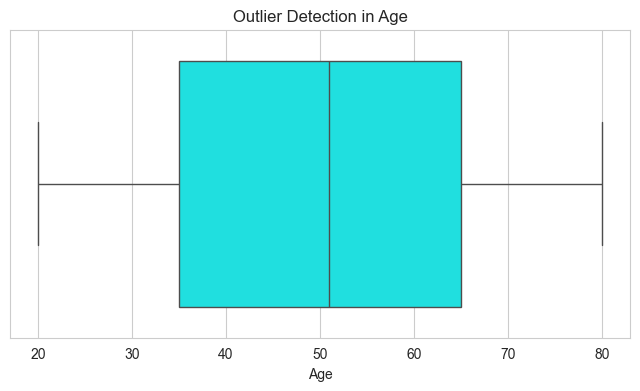

Age capped within range [-10.00, 110.00]


In [75]:
if 'Age' in df.columns:
    # Visualization of outliers
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df['Age'], color='cyan')
    plt.title('Outlier Detection in Age')
    plt.show()

    # IQR calculation
    Q1 = df['Age'].quantile(0.25)
    Q3 = df['Age'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df['Age'] = np.clip(df['Age'], lower_bound, upper_bound)
    print(f"Age capped within range [{lower_bound:.2f}, {upper_bound:.2f}]")

### 2.5 Normalize/Scale Data
- Scaling numerical features using StandardScaler.

In [76]:
if 'Age' in df.columns:
    scaler = StandardScaler()
    df['Age_Scaled'] = scaler.fit_transform(df[['Age']]) ##2d array making
    print("Applied StandardScaler to 'Age'.")
    display(df[['Age', 'Age_Scaled']].head())

Applied StandardScaler to 'Age'.


,Age,Age_Scaled
0,69,1.053151
1,61,0.599288
2,29,-1.216163
3,63,0.712754
4,46,-0.251705


### 2.6 Encode Categorical Variables
- Label Encoding for Target and One-Hot Encoding for categorical features.

In [77]:
df[categorical_value].nunique()

Patient_ID         1500
Gender                2
Symptoms             10
Medical_History      10
Medications           9
Lab_Reports          10
Lifestyle             6
Doctor_Notes         10
Diagnosis            10
Risk_Level            3
dtype: int64

We can drop Patients ID, it's the only identifier, So we can drop this as well.

In [78]:
df.drop(labels= "Patient_ID",inplace=True, axis=1)
df.columns

Index(['Age', 'Gender', 'Symptoms', 'Medical_History', 'Medications',
       'Lab_Reports', 'Lifestyle', 'Doctor_Notes', 'Diagnosis', 'Risk_Level',
       'Age_Scaled'],
      dtype='object')

In [48]:
print(f"Number of columns, {df.shape[1]}")

Number of columns, 12


In [49]:
# df.drop(labels = 'Age',inplace=True, axis=1)

In [79]:
le = LabelEncoder()

# Encoding Target variable
if 'Risk_Level' in df.columns:
    df['Risk_Level_Encoded'] = le.fit_transform(df['Risk_Level'])
    print(f"Encoded Risk_Level. Classes: {le.classes_}")

# Encoding Gender using One-Hot
if 'Gender' in df.columns:
    df = pd.get_dummies(df, columns=['Gender'], prefix='Gender')
    print("Applied One-Hot Encoding to 'Gender'.")

df.head()

Encoded Risk_Level. Classes: ['High' 'Low' 'Medium']
Applied One-Hot Encoding to 'Gender'.


,Age,Symptoms,Medical_History,Medications,Lab_Reports,Lifestyle,Doctor_Notes,Diagnosis,Risk_Level,Age_Scaled,Risk_Level_Encoded,Gender_Female,Gender_Male
0,69,"Memory loss, confusion",Stroke history,Ibuprofen,High blood sugar,Healthy diet,"Reports difficulty breathing, requires further...",Cancer Screening Needed,Medium,1.053151,2,True,False
1,61,"Shortness of breath, dizziness",Arthritis,Levothyroxine,High blood pressure,Smoker,"Nausea reported, possible gastrointestinal issue",Respiratory Infection,Medium,0.599288,2,False,True
2,29,"Shortness of breath, dizziness",Arthritis,Omeprazole,Irregular heartbeat detected,Drinker,"Sudden weight loss unexplained, requires evalu...",Migraine,Low,-1.216163,1,False,True
3,63,"High fever, body aches",Asthma,Aspirin,High cholesterol,Active,Mild symptoms but family history is concerning,Arthritis,Medium,0.712754,2,False,True
4,46,"Joint pain, swelling",No known history,Omeprazole,High blood sugar,Drinker,"Heart palpitations observed, needs ECG",Arthritis,Medium,-0.251705,2,True,False


### 2.7 Feature Engineering
- Creating new features like 'Symptom_Count'.

In [80]:
if 'Symptoms' in df.columns:
    # Calculate number of symptoms for each patient
    df['Symptom_Count'] = df['Symptoms'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
    print("Feature 'Symptom_Count' created.")

df.head()

Feature 'Symptom_Count' created.


,Age,Symptoms,Medical_History,Medications,Lab_Reports,Lifestyle,Doctor_Notes,Diagnosis,Risk_Level,Age_Scaled,Risk_Level_Encoded,Gender_Female,Gender_Male,Symptom_Count
0,69,"Memory loss, confusion",Stroke history,Ibuprofen,High blood sugar,Healthy diet,"Reports difficulty breathing, requires further...",Cancer Screening Needed,Medium,1.053151,2,True,False,2
1,61,"Shortness of breath, dizziness",Arthritis,Levothyroxine,High blood pressure,Smoker,"Nausea reported, possible gastrointestinal issue",Respiratory Infection,Medium,0.599288,2,False,True,2
2,29,"Shortness of breath, dizziness",Arthritis,Omeprazole,Irregular heartbeat detected,Drinker,"Sudden weight loss unexplained, requires evalu...",Migraine,Low,-1.216163,1,False,True,2
3,63,"High fever, body aches",Asthma,Aspirin,High cholesterol,Active,Mild symptoms but family history is concerning,Arthritis,Medium,0.712754,2,False,True,2
4,46,"Joint pain, swelling",No known history,Omeprazole,High blood sugar,Drinker,"Heart palpitations observed, needs ECG",Arthritis,Medium,-0.251705,2,True,False,2


## 3. Exploratory Data Analysis (EDA)

### 3.1 Understand Data Structure & Summary Statistics

In [81]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Information:")
df.info()

print("\nNumerical Summary Statistics:")
display(df.describe())

print("\nCategorical Summary Statistics:")
display(df.describe(include=['O']))

DataFrame Shape: (1500, 14)

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Symptoms            1500 non-null   object 
 2   Medical_History     1500 non-null   object 
 3   Medications         1500 non-null   object 
 4   Lab_Reports         1500 non-null   object 
 5   Lifestyle           1500 non-null   object 
 6   Doctor_Notes        1500 non-null   object 
 7   Diagnosis           1500 non-null   object 
 8   Risk_Level          1500 non-null   object 
 9   Age_Scaled          1500 non-null   float64
 10  Risk_Level_Encoded  1500 non-null   int64  
 11  Gender_Female       1500 non-null   bool   
 12  Gender_Male         1500 non-null   bool   
 13  Symptom_Count       1500 non-null   int64  
dtypes: bool(2), float64(1), int64(3), object(8)
memory u

,Age,Age_Scaled,Risk_Level_Encoded,Symptom_Count
count,1500.000000,1.500000e+03,1500.000000,1500.0
mean,50.436667,-4.559316e-17,0.971333,2.0
std,17.632354,1.000334e+00,0.818306,0.0
min,20.000000,-1.726758e+00,0.000000,2.0
25%,35.000000,-8.757659e-01,0.000000,2.0
50%,51.000000,3.195950e-02,1.000000,2.0
75%,65.000000,8.262192e-01,2.000000,2.0
max,80.000000,1.677212e+00,2.000000,2.0



Categorical Summary Statistics:


,Symptoms,Medical_History,Medications,Lab_Reports,Lifestyle,Doctor_Notes,Diagnosis,Risk_Level
count,1500,1500,1500,1500,1500,1500,1500,1500
unique,10,10,9,10,6,10,10,3
top,"Blurred vision, headaches",Cancer history,Lisinopril,Low oxygen levels,Smoker,"Blurry vision, check for diabetes",Heart Disease,High
freq,171,170,329,168,261,164,175,524


### 3.2 Univariate Analysis
- Single variable distributions.

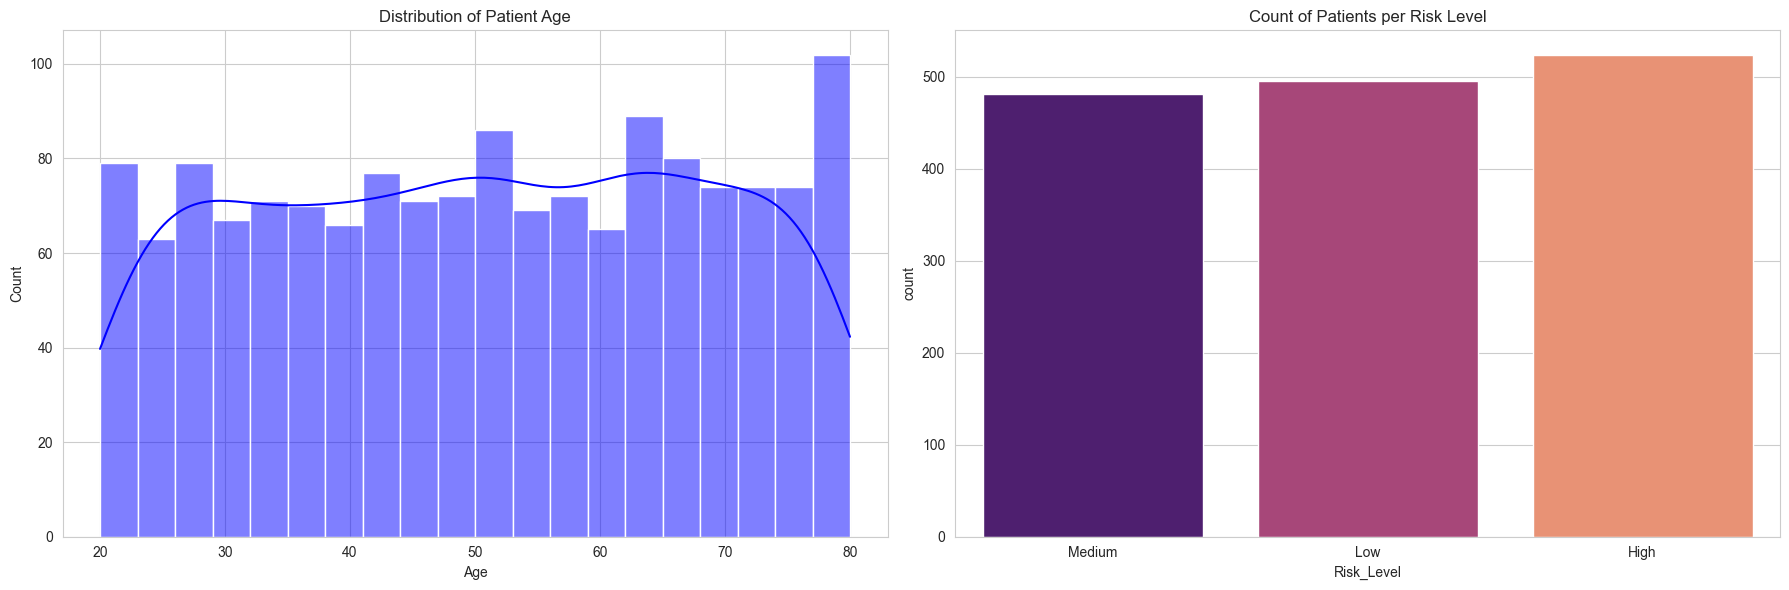

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Histogram for Age
sns.histplot(df['Age'], bins=20, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Patient Age')

# Bar plot for Risk Level
if 'Risk_Level' in df.columns:
    sns.countplot(x='Risk_Level', hue= 'Risk_Level', data=df, ax=ax[1], palette='magma')
    ax[1].set_title('Count of Patients per Risk Level')

plt.tight_layout()
plt.show()

In [83]:
categorical_value.remove('Patient_ID')
categorical_value.remove('Gender')

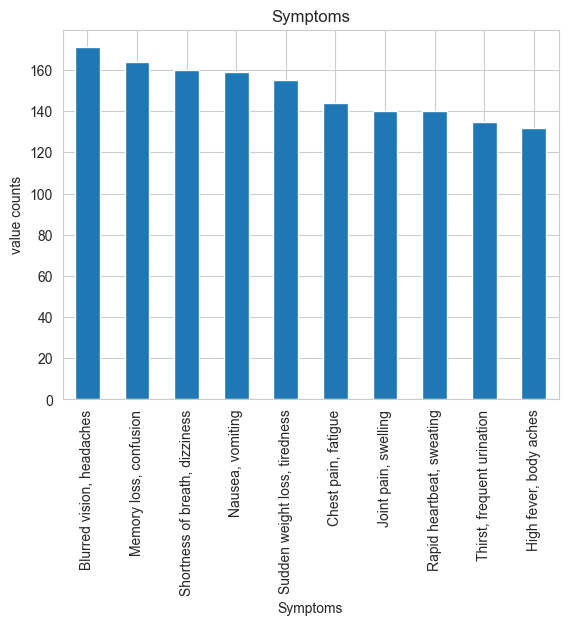

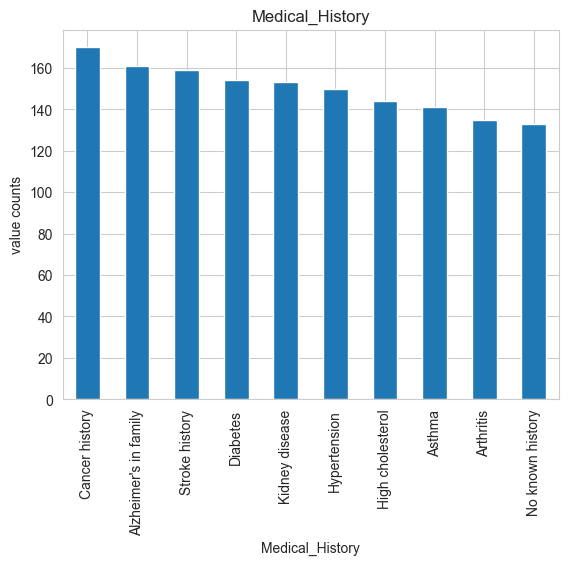

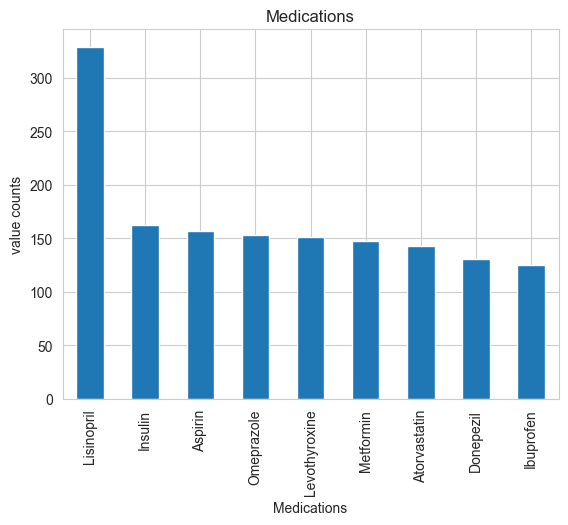

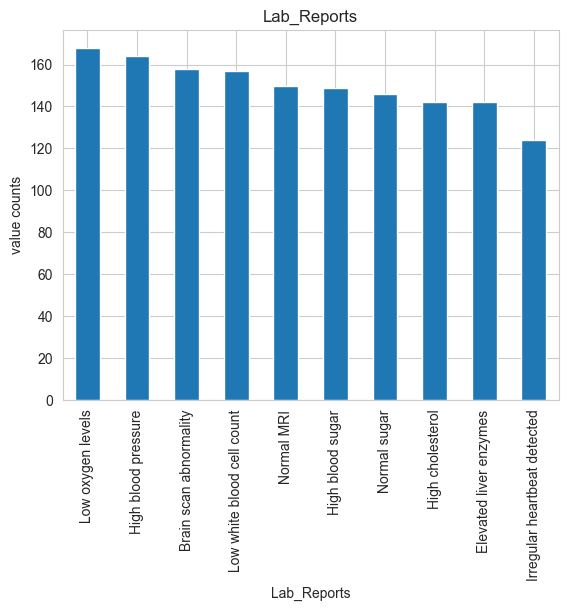

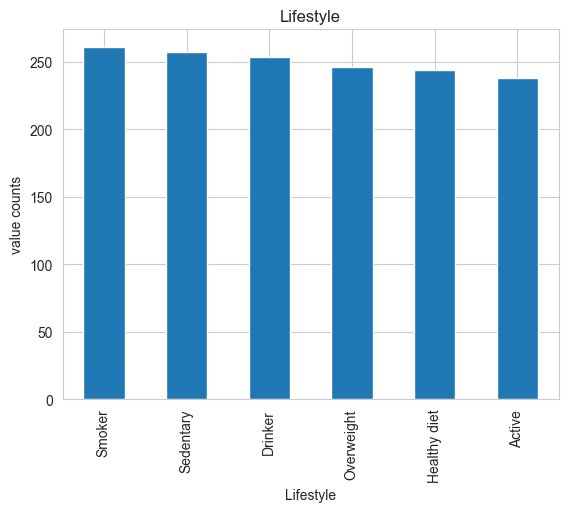

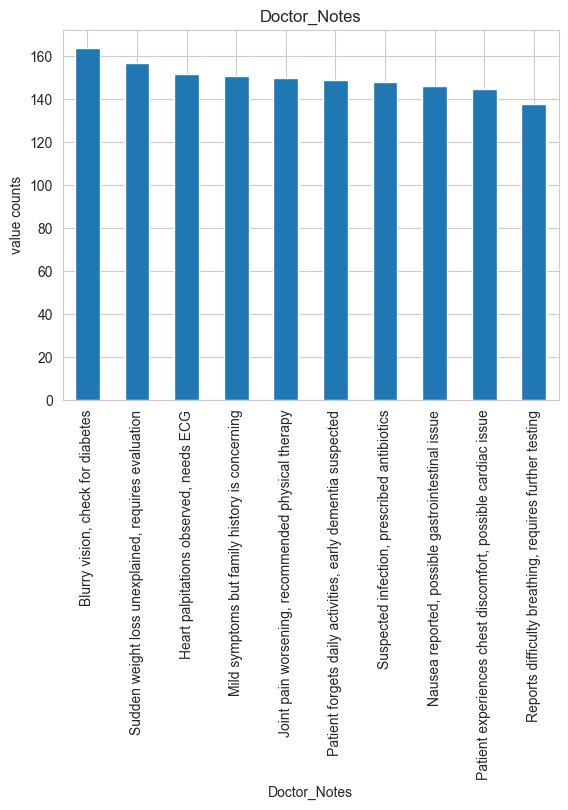

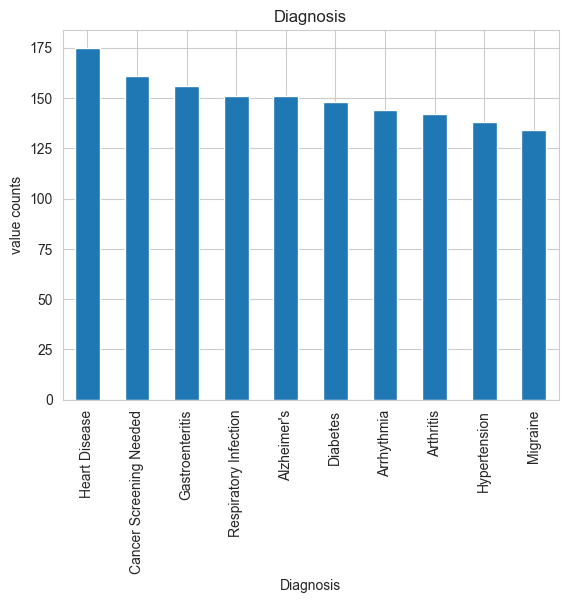

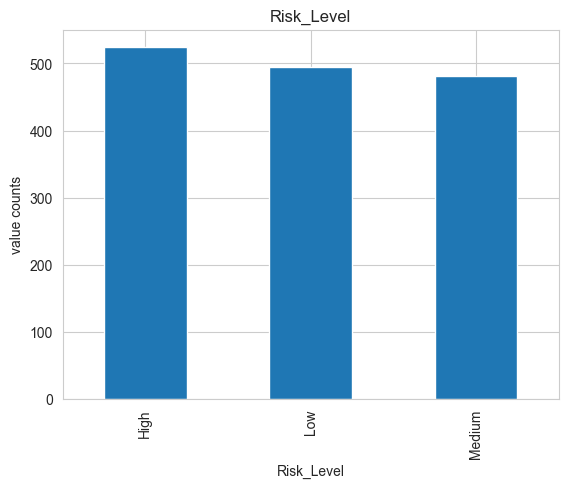

In [84]:
for i in df[categorical_value]:
    df[i].value_counts().plot(kind='bar', xlabel = i , ylabel='value counts', title = i)
    print('\n')
    plt.show()


## 3.3  Bivariate Analysis
- Relationships between two variables.

All the risk level as same age distribution: !!!

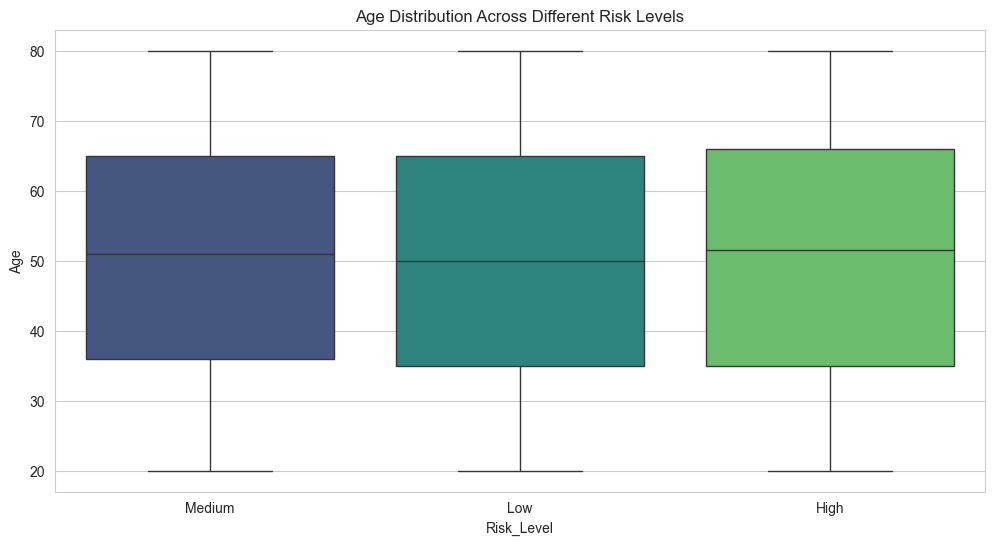

In [85]:
if 'Age' in df.columns and 'Risk_Level' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Risk_Level', hue='Risk_Level', y='Age', data=df, palette='viridis')
    plt.title('Age Distribution Across Different Risk Levels')
    plt.show()



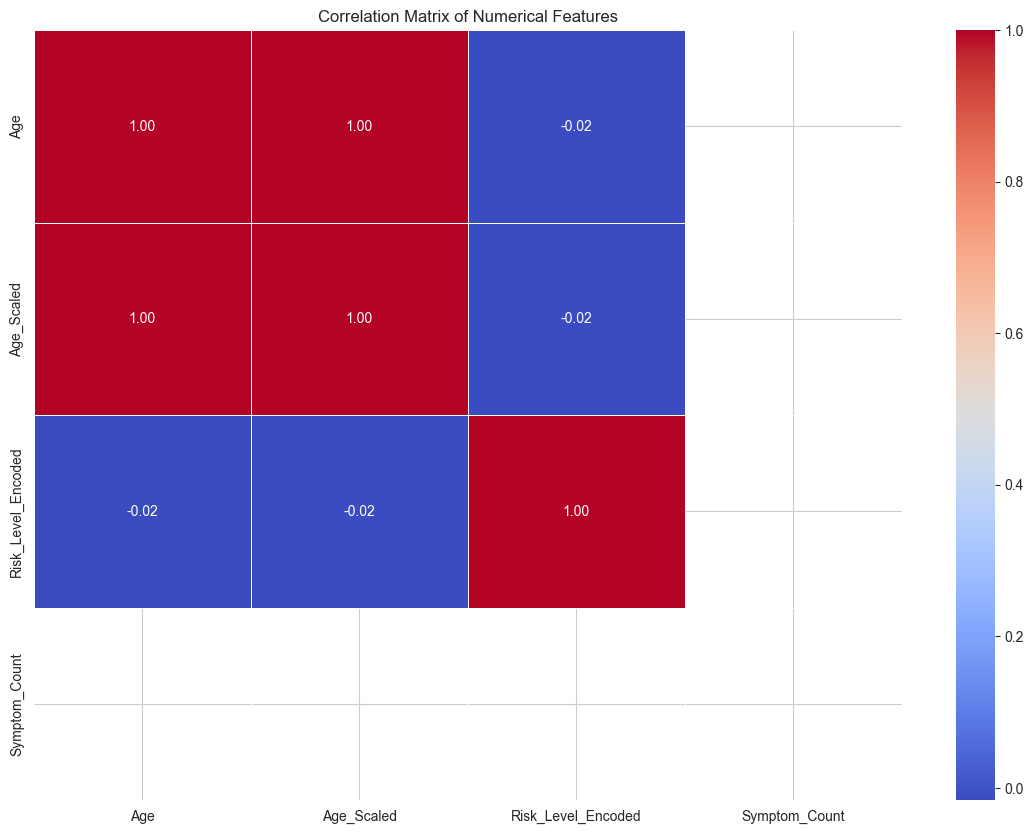

In [86]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

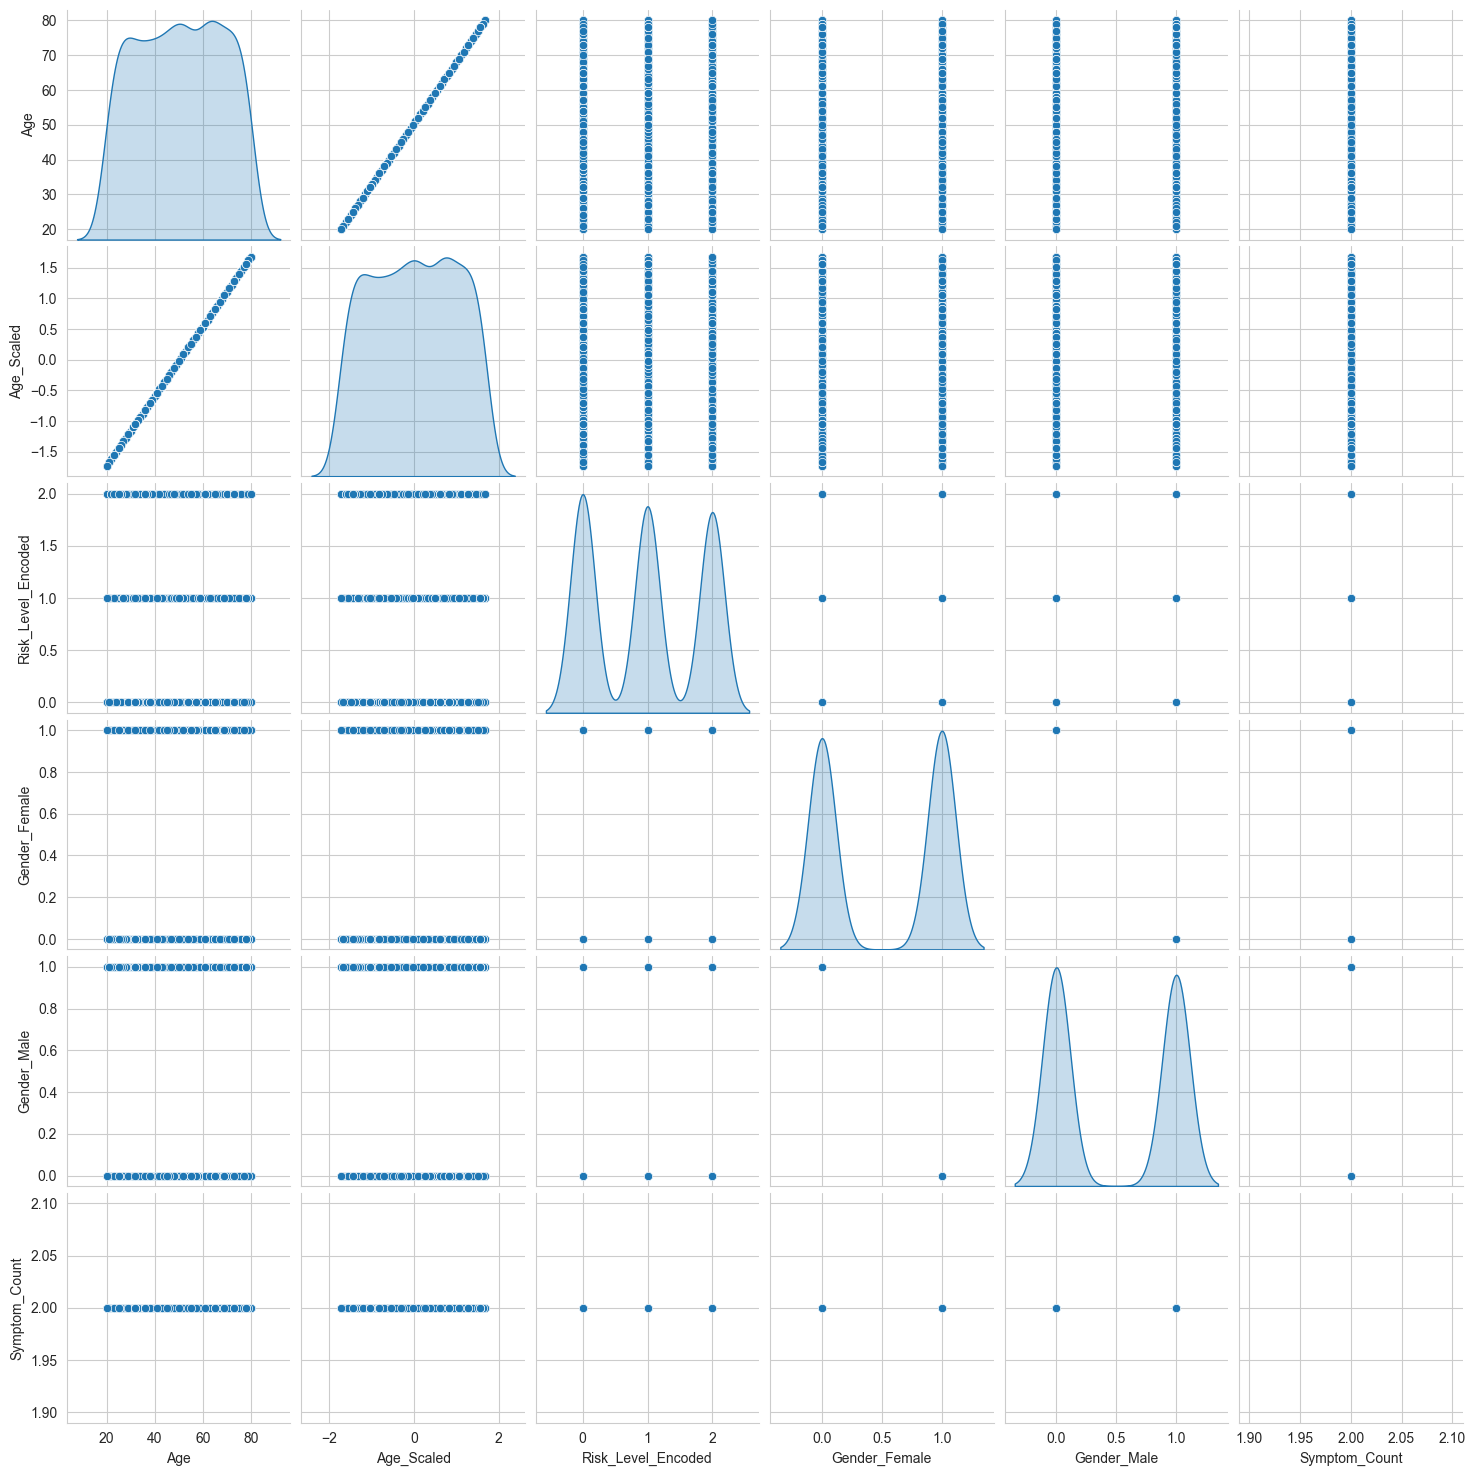

In [87]:
sns.pairplot(df,diag_kind='kde')
plt.show()

### 3.4 Multivariate Analysis
- Insights from multiple variables simultaneously (PCA).

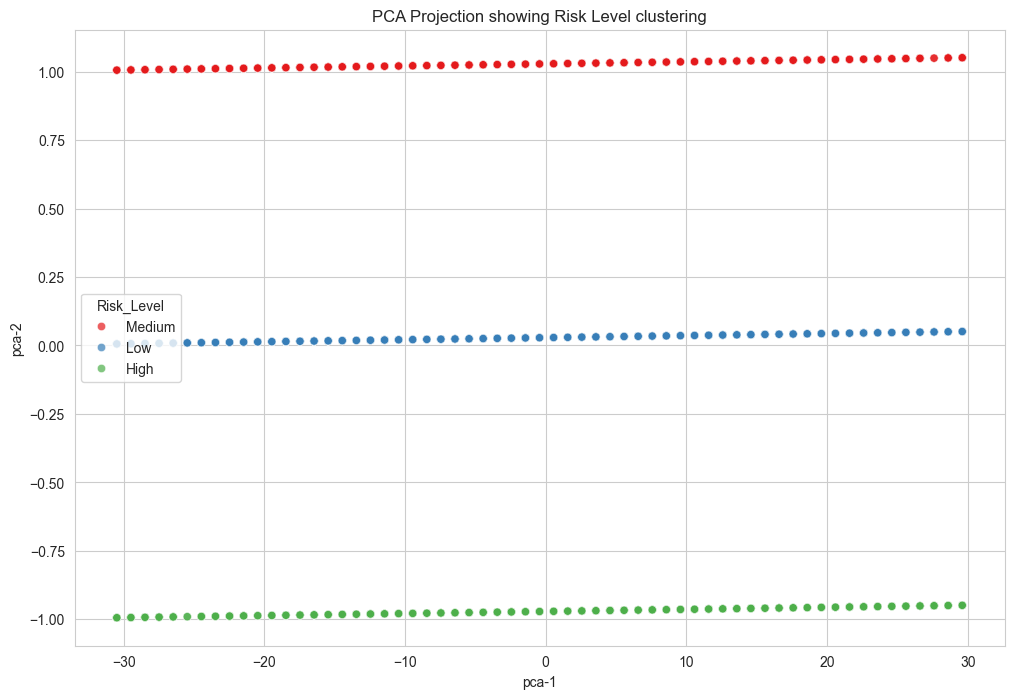

In [56]:
# Dimensionality Reduction with PCA
pca = PCA(n_components=2)
num_data = df.select_dtypes(include=[np.number]).fillna(0)
pca_results = pca.fit_transform(num_data)

df['pca-1'] = pca_results[:,0]
df['pca-2'] = pca_results[:,1]

if 'Risk_Level' in df.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='pca-1', y='pca-2', hue='Risk_Level', data=df, palette='Set1', alpha=0.7)
    plt.title('PCA Projection showing Risk Level clustering')
    plt.show()

### 3.5 Check Relationships & Aggregations

In [57]:
if 'Risk_Level' in df.columns:
    # Aggregate numerical stats by Risk Level
    print("Average metrics by Risk Level:")
    display(df.groupby('Risk_Level')[['Age', 'Symptom_Count']].mean())

Average metrics by Risk Level:


,Age,Symptom_Count
Risk_Level,,
High,50.772901,2.0
Low,50.434343,2.0
Medium,50.072765,2.0


### 3.6 Pattern Detection and Top Symptoms

In [58]:
if 'Symptoms' in df.columns and 'Risk_Level' in df.columns:
    results = []
    for level in df['Risk_Level'].unique():
        # Extract and flatten list of symptoms
        syms = df[df['Risk_Level'] == level]['Symptoms'].str.split(',').explode().str.strip()
        top_3 = syms.value_counts().head(3).index.tolist()
        results.append({'Risk_Level': level, 'Most Common Symptoms': ", ".join(top_3)})
    
    display(pd.DataFrame(results))

,Risk_Level,Most Common Symptoms
0,Medium,"headaches, Blurred vision, vomiting"
1,Low,"Chest pain, fatigue, Blurred vision"
2,High,"confusion, Memory loss, dizziness"
